In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
sales = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Online_Sales.csv")
customers = pd.read_excel(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\CustomersData.xlsx")
coupon = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Discount_Coupon.csv")
marketing = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Marketing_Spend.csv")
tax = pd.read_excel(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Tax_amount.xlsx")

In [3]:
dfs = [sales, customers, coupon, marketing, tax]

for df in dfs:
    df.columns = (df.columns.str.strip().str.replace(' ', '_'))

In [4]:
sales['Transaction_Date'] = pd.to_datetime(
    sales['Transaction_Date'].astype(str),
    format='%Y%m%d'
)

In [5]:
marketing['Date'] = pd.to_datetime(marketing['Date'])

In [6]:
sales['Month'] = sales['Transaction_Date'].dt.strftime('%b')
sales['YearMonth'] = sales['Transaction_Date'].dt.strftime('%Y-%m')
sales['Week'] = sales['Transaction_Date'].dt.isocalendar().week
sales['Day'] = sales['Transaction_Date'].dt.day_name()

In [7]:
sales['Product_Category'] = sales['Product_Category'].str.strip()
coupon['Product_Category'] = coupon['Product_Category'].str.strip()

sales = sales.merge(
    coupon,
    on=['Month', 'Product_Category'],
    how='left'
)

sales['Discount_pct'] = sales['Discount_pct'].fillna(0)

In [8]:
sales = sales.merge(
    tax,
    on='Product_Category',
    how='left'
)

In [9]:
sales['Invoice_Value'] = (
    (
        sales['Quantity']
        * sales['Avg_Price']
        * (1 - sales['Discount_pct']/100)
        * (1 + sales['GST']/100)
    )
    + sales['Delivery_Charges']
)

In [10]:
sales.shape

(52924, 18)

In [11]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  int64         
 1   Transaction_ID       52924 non-null  int64         
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  Month                52924 non-null  object        
 11  YearMonth            52924 non-null  object        
 12  Week                 52924 non-null  UInt32        
 13  Day                  52924 non-

In [12]:
sales.describe()

,CustomerID,Transaction_ID,Transaction_Date,Quantity,Avg_Price,Delivery_Charges,Week,Discount_pct,GST,Invoice_Value
count,52924.00000,52924.000000,52924,52924.000000,52924.000000,52924.000000,52924.0,52924.000000,52924.000000,52924.000000
mean,15346.70981,32409.825675,2019-07-05 19:16:09.450532864,4.497638,52.237646,10.517630,27.078679,19.802358,0.137462,81.354430
min,12346.00000,16679.000000,2019-01-01 00:00:00,1.000000,0.390000,0.000000,1.0,0.000000,0.050000,3.714674
25%,13869.00000,25384.000000,2019-04-12 00:00:00,1.000000,5.700000,6.000000,15.0,10.000000,0.100000,16.819440
50%,15311.00000,32625.500000,2019-07-13 00:00:00,1.000000,16.990000,6.000000,28.0,20.000000,0.180000,36.253460
75%,16996.25000,39126.250000,2019-09-27 00:00:00,2.000000,102.130000,6.500000,39.0,30.000000,0.180000,112.922316
max,18283.00000,48497.000000,2019-12-31 00:00:00,900.000000,355.740000,521.360000,52.0,30.000000,0.180000,8556.272750
std,1766.55602,8648.668977,NaN,20.104711,64.006882,19.475613,14.536834,8.278878,0.045825,139.236581


In [13]:
sales.isnull().sum()

CustomerID               0
Transaction_ID           0
Transaction_Date         0
Product_SKU              0
Product_Description      0
Product_Category         0
Quantity                 0
Avg_Price                0
Delivery_Charges         0
Coupon_Status            0
Month                    0
YearMonth                0
Week                     0
Day                      0
Coupon_Code            400
Discount_pct             0
GST                      0
Invoice_Value            0
dtype: int64

In [14]:
sales.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,YearMonth,Week,Day,Coupon_Code,Discount_pct,GST,Invoice_Value
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan,2019-01,1,Tuesday,ELEC10,10.0,0.10,144.977339
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan,2019-01,1,Tuesday,ELEC10,10.0,0.10,144.977339
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,Jan,2019-01,1,Tuesday,OFF10,10.0,0.10,8.346845
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,Jan,2019-01,1,Tuesday,SALE10,10.0,0.18,85.526993
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,Jan,2019-01,1,Tuesday,AIO10,10.0,0.18,21.376730


In [15]:
total_revenue = sales['Invoice_Value'].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 4305601.85


In [16]:
sales['Transaction_ID'].nunique()

25061

In [17]:
sales['CustomerID'].nunique()

1468

In [18]:
monthly_revenue = (
    sales.groupby('YearMonth')
    ['Invoice_Value']
    .sum()
    .reset_index()
)

monthly_revenue

,YearMonth,Invoice_Value
0,2019-01,423172.633400
1,2019-02,298666.918902
2,2019-03,307003.042928
3,2019-04,403861.577522
4,2019-05,288670.114666
5,2019-06,263140.033943
6,2019-07,384806.358026
7,2019-08,382778.132330
8,2019-09,293889.785084
9,2019-10,415195.195895


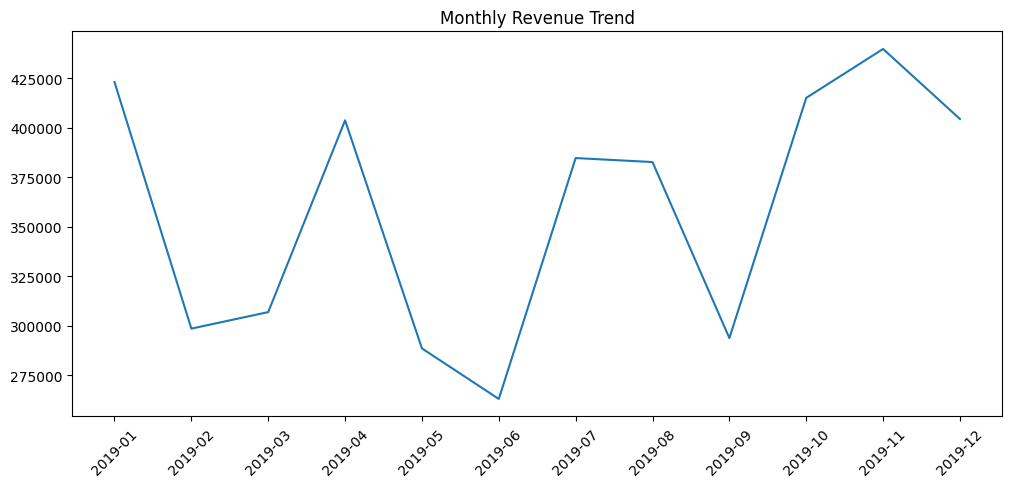

In [19]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue['YearMonth'],
    monthly_revenue['Invoice_Value']
)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.show()

In [20]:
monthly_orders = (
    sales.groupby('YearMonth')
    ['Transaction_ID']
    .nunique()
    .reset_index(name='Orders')
)

monthly_orders

,YearMonth,Orders
0,2019-01,2102
1,2019-02,1664
2,2019-03,1991
3,2019-04,1813
4,2019-05,2034
5,2019-06,1940
6,2019-07,2080
7,2019-08,2414
8,2019-09,1932
9,2019-10,2125


In [21]:
monthly_customers = (
    sales.groupby('YearMonth')
    ['CustomerID']
    .nunique()
    .reset_index(name='Customers')
)

monthly_customers

,YearMonth,Customers
0,2019-01,215
1,2019-02,109
2,2019-03,208
3,2019-04,224
4,2019-05,200
5,2019-06,259
6,2019-07,236
7,2019-08,300
8,2019-09,193
9,2019-10,210


In [22]:
first_purchase = sales.groupby('CustomerID')['Transaction_Date'].min().reset_index()

first_purchase['Acquisition_Month'] = (
    first_purchase['Transaction_Date'].dt.strftime('%Y-%m')
)

customer_acquisition = (
    first_purchase.groupby('Acquisition_Month')['CustomerID']
    .nunique()
    .reset_index(name='New_Customers')
)

customer_acquisition

,Acquisition_Month,New_Customers
0,2019-01,215
1,2019-02,96
2,2019-03,177
3,2019-04,163
4,2019-05,112
5,2019-06,137
6,2019-07,94
7,2019-08,135
8,2019-09,78
9,2019-10,87


In [23]:
sales['YearMonth'] = sales['Transaction_Date'].dt.strftime('%Y-%m')

customer_month = sales[['CustomerID','YearMonth']].drop_duplicates()

retention = pd.crosstab(
    customer_month['CustomerID'],
    customer_month['YearMonth']
)

retention.head()

YearMonth,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12
CustomerID,,,,,,,,,,,,
12346,0,0,0,0,0,0,0,0,1,0,0,0
12347,0,0,1,0,0,0,0,0,0,0,1,0
12348,0,0,0,0,0,1,0,0,0,1,0,0
12350,0,0,0,0,0,0,0,0,0,0,0,1
12356,0,0,0,0,0,0,0,0,1,0,0,0


In [24]:
first_purchase = sales.groupby('CustomerID')['Transaction_Date'].min()

sales['Customer_Type'] = np.where(
    sales['Transaction_Date'].dt.to_period('M') ==
    sales['CustomerID'].map(first_purchase).dt.to_period('M'),
    'New',
    'Existing'
)

sales.groupby(
    ['YearMonth','Customer_Type']
)['Invoice_Value'].sum()

YearMonth  Customer_Type
2019-01    New              423172.633400
2019-02    Existing          37478.011237
           New              261188.907665
2019-03    Existing          52517.555655
           New              254485.487273
2019-04    Existing         164724.447770
           New              239137.129753
2019-05    Existing         104291.912479
           New              184378.202187
2019-06    Existing         106240.287937
           New              156899.746006
2019-07    Existing         231425.033458
           New              153381.324568
2019-08    Existing         199894.378760
           New              182883.753570
2019-09    Existing         172995.410042
           New              120894.375041
2019-10    Existing         192414.571552
           New              222780.624343
2019-11    Existing         251378.877337
           New              188522.782017
2019-12    Existing         213062.091965
           New              191454.304106
Name: Inv

In [25]:
sales.groupby('Discount_pct').agg(
    Revenue=('Invoice_Value','sum'),
    Orders=('Transaction_ID','nunique')
)

,Revenue,Orders
Discount_pct,,
0.0,3.354870e+04,370
10.0,1.612722e+06,8104
20.0,1.399639e+06,8367
30.0,1.259692e+06,8529


In [26]:
sales.groupby('YearMonth')['Invoice_Value'].sum()

YearMonth
2019-01    423172.633400
2019-02    298666.918902
2019-03    307003.042928
2019-04    403861.577522
2019-05    288670.114666
2019-06    263140.033943
2019-07    384806.358026
2019-08    382778.132330
2019-09    293889.785084
2019-10    415195.195895
2019-11    439901.659354
2019-12    404516.396071
Name: Invoice_Value, dtype: float64

In [27]:
sales.groupby('YearMonth')['Transaction_ID'].nunique()

YearMonth
2019-01    2102
2019-02    1664
2019-03    1991
2019-04    1813
2019-05    2034
2019-06    1940
2019-07    2080
2019-08    2414
2019-09    1932
2019-10    2125
2019-11    2282
2019-12    2684
Name: Transaction_ID, dtype: int64

In [28]:
sales.groupby('YearMonth')['Quantity'].sum()

YearMonth
2019-01    20140
2019-02    16575
2019-03    20787
2019-04    25277
2019-05    18715
2019-06    21619
2019-07    22898
2019-08    27457
2019-09    19353
2019-10    17425
2019-11    15120
2019-12    12667
Name: Quantity, dtype: int64

In [29]:
sales.groupby('YearMonth')['CustomerID'].nunique()

YearMonth
2019-01    215
2019-02    109
2019-03    208
2019-04    224
2019-05    200
2019-06    259
2019-07    236
2019-08    300
2019-09    193
2019-10    210
2019-11    188
2019-12    236
Name: CustomerID, dtype: int64

In [30]:
aov = (
    sales.groupby('YearMonth')['Invoice_Value'].sum()
    /
    sales.groupby('YearMonth')['Transaction_ID'].nunique()
)

aov

YearMonth
2019-01    201.319045
2019-02    179.487331
2019-03    154.195401
2019-04    222.758730
2019-05    141.922377
2019-06    135.639193
2019-07    185.003057
2019-08    158.565921
2019-09    152.116866
2019-10    195.385975
2019-11    192.770228
2019-12    150.714007
dtype: float64

In [31]:
sales.groupby(
    ['YearMonth','Product_Category']
)['Invoice_Value'].sum()

YearMonth  Product_Category    
2019-01    Accessories                 52.959413
           Android                     92.882816
           Apparel                  50063.020409
           Backpacks                  309.478190
           Bags                     12893.500881
                                       ...      
2019-12    Nest-Canada               3933.806903
           Nest-USA                208507.437084
           Notebooks & Journals       756.169876
           Office                   16687.889892
           Waze                       887.641300
Name: Invoice_Value, Length: 207, dtype: float64

In [32]:
sales_customer = sales.merge(
    customers,
    on='CustomerID',
    how='left'
)

sales_customer.groupby('Location')[
    'Invoice_Value'
].sum()

Location
California       1.330316e+06
Chicago          1.495451e+06
New Jersey       3.713032e+05
New York         8.730655e+05
Washington DC    2.354656e+05
Name: Invoice_Value, dtype: float64

In [33]:
sales.groupby('Day').agg(
    Revenue=('Invoice_Value','sum'),
    Orders=('Transaction_ID','nunique')
)

,Revenue,Orders
Day,,
Friday,794767.960267,4233
Monday,326859.414403,2130
Saturday,632109.400027,3872
Sunday,645105.661843,3855
Thursday,780327.863796,4278
Tuesday,360432.861006,2315
Wednesday,765998.686780,4378


In [34]:
marketing['YearMonth'] = marketing['Date'].dt.strftime('%Y-%m')

marketing_monthly = (
    marketing.groupby('YearMonth')
    [['Offline_Spend','Online_Spend']]
    .sum()
)

marketing_monthly['Marketing_Spend'] = (
    marketing_monthly['Offline_Spend']
    +
    marketing_monthly['Online_Spend']
)

In [35]:
monthly_revenue = (
    sales.groupby('YearMonth')
    ['Invoice_Value']
    .sum()
)

In [36]:
summary = pd.concat(
    [monthly_revenue, marketing_monthly],
    axis=1
)

summary['Marketing_%'] = (
    summary['Marketing_Spend']
    /
    summary['Invoice_Value']
) * 100

In [37]:
summary

,Invoice_Value,Offline_Spend,Online_Spend,Marketing_Spend,Marketing_%
YearMonth,,,,,
2019-01,423172.633400,96600,58328.95,154928.95,36.611288
2019-02,298666.918902,81300,55807.92,137107.92,45.906631
2019-03,307003.042928,73500,48750.09,122250.09,39.820482
2019-04,403861.577522,96000,61026.83,157026.83,38.881349
2019-05,288670.114666,65500,52759.64,118259.64,40.967053
2019-06,263140.033943,80500,53818.14,134318.14,51.044358
2019-07,384806.358026,67500,52717.85,120217.85,31.241129
2019-08,382778.132330,85500,57404.15,142904.15,37.333415
2019-09,293889.785084,83000,52514.54,135514.54,46.110667


In [38]:
sales['Tax_Amount'] = (
    sales['Quantity']
    * sales['Avg_Price']
    * (1 - sales['Discount_pct']/100)
    * (sales['GST']/100)
)

In [39]:
delivery = (
    sales.groupby('YearMonth')
    ['Delivery_Charges']
    .sum()
)

summary['Delivery_%'] = (
    delivery
    /
    summary['Invoice_Value']
) * 100

In [40]:
summary[['Marketing_Spend','Invoice_Value']].corr()

,Marketing_Spend,Invoice_Value
Marketing_Spend,1.000000,0.626784
Invoice_Value,0.626784,1.000000


In [41]:
sales.groupby(
    'Product_Description'
)['Transaction_ID'].count().sort_values(
    ascending=False
).head(10)

Product_Description
Nest Learning Thermostat 3rd Gen-USA - Stainless Steel    3511
Nest Cam Outdoor Security Camera - USA                    3328
Nest Cam Indoor Security Camera - USA                     3230
Google Sunglasses                                         1523
Nest Protect Smoke + CO White Battery Alarm-USA           1361
Nest Learning Thermostat 3rd Gen-USA - White              1089
Nest Protect Smoke + CO White Wired Alarm-USA             1065
Google 22 oz Water Bottle                                  902
Nest Thermostat E - USA                                    844
Google Laptop and Cell Phone Stickers                      806
Name: Transaction_ID, dtype: int64

In [42]:
sales.groupby(
    'Product_Description'
)['Quantity'].sum().sort_values(
    ascending=False
).head(10)

Product_Description
Maze Pen                                  16234
Google 22 oz Water Bottle                 14282
Google Sunglasses                         11452
Sport Bag                                  7321
Google Metallic Notebook Set               6496
Google Laptop and Cell Phone Stickers      5847
Google Kick Ball                           5549
Recycled Paper Journal Set                 5381
Nest Cam Outdoor Security Camera - USA     5206
Foam Can and Bottle Cooler                 5098
Name: Quantity, dtype: int64